## Importing all Required Libraries

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Custom Hough Line Transform

In [2]:
def hough_line(img):
    height, width = img.shape
    maxdist = int(np.round(np.sqrt(height**2 + width**2)))
    rhos   = np.linspace(-maxdist, maxdist, maxdist * 2)
    thetas = np.deg2rad(np.arange(-90, 90))
 
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
 
    y_idxs, x_idxs = np.nonzero(img)  # get edge points
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        for t_idx in range(len(thetas)):
            theta = thetas[t_idx]
            rho = int(x * np.cos(theta) + y * np.sin(theta)) + maxdist
            accumulator[rho, t_idx] += 1
 
    return accumulator, rhos, thetas

### Test Hough on a Synthetic Single-Point Image

Peak: rho = -49.62,  theta = -90.00°


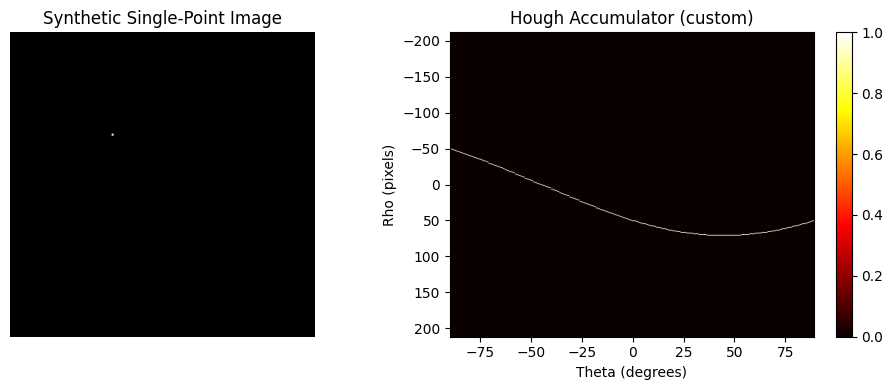

In [3]:
image_test = np.zeros((150, 150), dtype=np.uint8)
image_test[50, 50] = 1
accumulator, rhos, thetas = hough_line(image_test)
idx = np.argmax(accumulator)
rho_idx, theta_idx = np.unravel_index(idx, accumulator.shape)
print(f'Peak: rho = {rhos[rho_idx]:.2f},  theta = {np.rad2deg(thetas[theta_idx]):.2f}°')
 
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_test, cmap='gray')
plt.title('Synthetic Single-Point Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(accumulator, cmap='hot', aspect='auto',
           extent=[np.rad2deg(thetas[0]), np.rad2deg(thetas[-1]), rhos[-1], rhos[0]])
plt.title('Hough Accumulator (custom)')
plt.xlabel('Theta (degrees)')
plt.ylabel('Rho (pixels)')
plt.colorbar()
plt.tight_layout()
plt.show()

## Built-In CV2 Hough Lines (Standard & Probabilistic)

In [4]:
img = cv2.imread('pexels-artempodrez-5025500.jpg')
print(img.shape)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (400, 500))
print(img.shape)
 
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img1 = img.copy()  # for HoughLines (standard)
img2 = img.copy()  # for HoughLinesP (probabilistic)
 
edges = cv2.Canny(gray, 200, 230, apertureSize=3)

(3840, 2160, 3)
(500, 400, 3)


### Standard

In [5]:
lines_std = cv2.HoughLines(edges, 1, np.pi / 180, threshold=150)
# rho, theta → convert to x1,y1,x2,y2 endpoints
if lines_std is not None:
    for rho, theta in lines_std[:, 0]:
        a  = np.cos(theta);  b  = np.sin(theta)
        x0 = a * rho;        y0 = b * rho
        x1 = int(x0 + 1000 * (-b));  y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b));  y2 = int(y0 - 1000 * (a))
        cv2.line(img1, (x1, y1), (x2, y2), (255, 0, 0), 2)  # point1, point2, color, thickness
print(f'Standard HoughLines detected: {len(lines_std) if lines_std is not None else 0}')

Standard HoughLines detected: 5


## Probabilistic

In [6]:
minLineLength = 50
maxLineGap    = 5
lines_p = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=150,
                           minLineLength=minLineLength, maxLineGap=maxLineGap)
# returns (x1,y1,x2,y2) directly
if lines_p is not None:
    for x1, y1, x2, y2 in lines_p[:, 0]:
        cv2.line(img2, (x1, y1), (x2, y2), (255, 0, 0), 2)  # point1, point2, color, thickness
print(f'Probabilistic HoughLinesP detected: {len(lines_p) if lines_p is not None else 0}')

Probabilistic HoughLinesP detected: 5


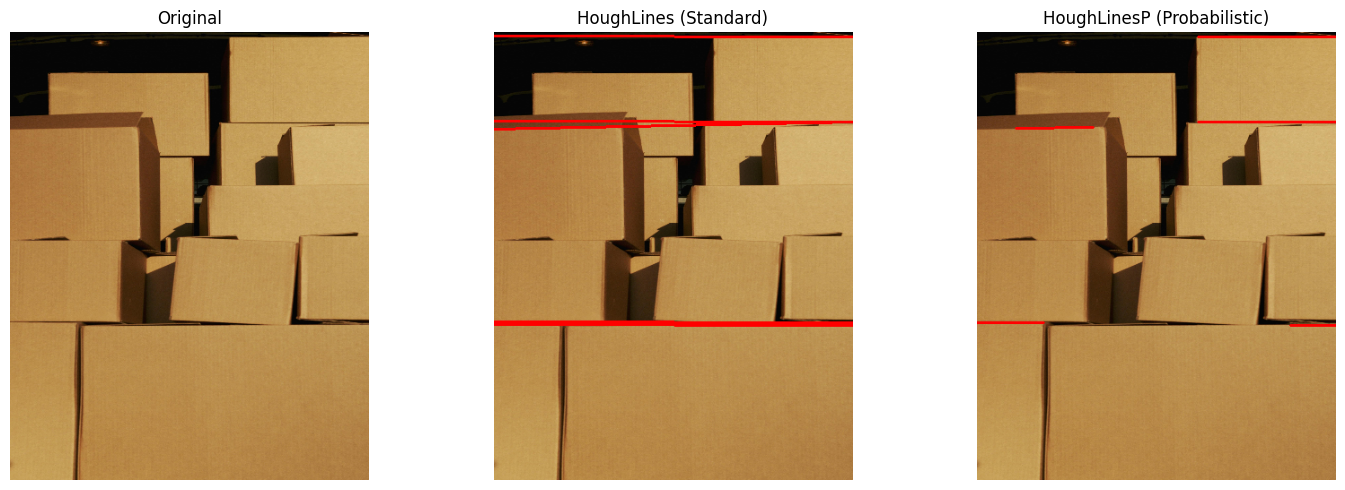

In [7]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img);   plt.title('Original');              plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(img1);  plt.title('HoughLines (Standard)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(img2);  plt.title('HoughLinesP (Probabilistic)'); plt.axis('off')
plt.tight_layout()
plt.show()

### Built In Hough Circles

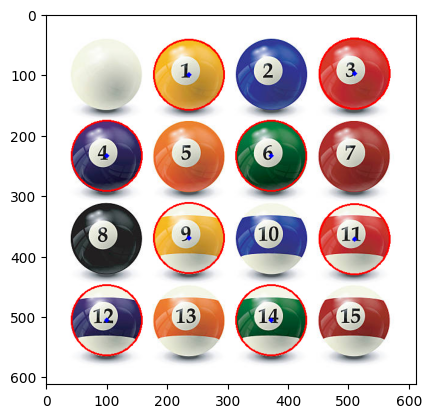

In [8]:
b_img  = cv2.imread('istockphoto-530757900-612x612.jpg')
b_img  = cv2.cvtColor(b_img, cv2.COLOR_BGR2RGB)
b_gray = cv2.cvtColor(b_img, cv2.COLOR_RGB2GRAY)
b_gray = cv2.medianBlur(b_gray, 3)  # image, kernel size — smooth to reduce noise
 
circles = cv2.HoughCircles(
    b_gray,
    cv2.HOUGH_GRADIENT,
    dp       = 1,    # inverse ratio of accumulator resolution vs image resolution
    minDist  = 150,  # minimum distance between circle centres
    param1   = 50,   # upper Canny threshold (lower = param1/2)
    param2   = 30,   # accumulator threshold — smaller → more false circles
    minRadius= 20,
    maxRadius= 60
)
 
circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    # draw the outer circle
    cv2.circle(b_img, (i[0], i[1]), i[2], (255, 0, 0), 2) # point, radius, color, thickness
    # draw the center of the circle
    cv2.circle(b_img, (i[0], i[1]), 2, (0, 0, 255), 3) # point, radius, color, thickness
plt.imshow(b_img)